In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import Bounds, LinearConstraint, milp
from scipy import sparse

#เปลี่ยนข้อมูลแค่ตรงนี้*** -_-
INPUT_FILE = Path('test_case_01_normal_balanced.csv')
OUTPUT_DIR = Path('outputs_optimize')
OUTPUT_FILE = OUTPUT_DIR / 'club_assignment.xlsx'

ROUNDS = 4
MAX_PER_CLUB = 20
MAX_RANK = 10
#เปลี่ยนข้อมูลแค่ตรงนี้*** -_-

STUDENT_ID = 'รหัสนักศึกษา'
STUDENT_NAME = 'ชื่อ นามสกุล'

OUTPUT_DIR.mkdir(exist_ok=True)
df = pd.read_excel(INPUT_FILE)
df.head()

,รหัสนักศึกษา,ชื่อ นามสกุล,ชมรมช่วงเช้า [อันดับที่ 1],ชมรมช่วงเช้า [อันดับที่ 2],ชมรมช่วงเช้า [อันดับที่ 3],ชมรมช่วงเช้า [อันดับที่ 4],ชมรมช่วงเช้า [อันดับที่ 5],ชมรมช่วงเช้า [อันดับที่ 6],ชมรมช่วงเช้า [อันดับที่ 7],ชมรมช่วงเช้า [อันดับที่ 8],...,ชมรมช่วงบ่าย [อันดับที่ 1],ชมรมช่วงบ่าย [อันดับที่ 2],ชมรมช่วงบ่าย [อันดับที่ 3],ชมรมช่วงบ่าย [อันดับที่ 4],ชมรมช่วงบ่าย [อันดับที่ 5],ชมรมช่วงบ่าย [อันดับที่ 6],ชมรมช่วงบ่าย [อันดับที่ 7],ชมรมช่วงบ่าย [อันดับที่ 8],ชมรมช่วงบ่าย [อันดับที่ 9],ชมรมช่วงบ่าย [อันดับที่ 10]
0,690710081,ปภาดา ปฐมเนติกุล,Cheerleader,Badminton,Chorus,Devil,Art,Swimming,Tennis,Track,...,CMSO,Porch,IMSU,Music,Thai fencing,E-Sport,LIBIR,Research,MUAN,Little Doctor
1,690710061,ธัญญรัศม์ กิตติสุนทรพิศาล,Track,Tennis,Badminton,Swimming,Patanque,Bridge,Devil,Chorus,...,Porch,CMSO,Little Doctor,MUAN,Thai fencing,E-Sport,Music,Thai Music,Cover dance,IMSU
2,690710019,จินดาภา วีระวนิชกุล,Badminton,Art,Swimming,Tennis,Volleyball,Basketball,Patanque,Devil,...,Research,Thai Music,LIBIR,IMSU,Cover dance,Little Doctor,Thai fencing,Music,MUAN,Porch
3,690710012,กิตติคุณ สายโอ๊ะ,Football,Track,Art,Chorus,Devil,Table Tennis,Badminton,Swimming,...,Research,Music,MCCC,MUAN,Little Doctor,E-Sport,CMSO,LIBIR,IMSU,Cover dance
4,690710163,ชนกันต์ ทวีวัชราเดช,Devil,Art,Chorus,Swimming,Patanque,Tennis,Track,Table Tennis,...,Thai Music,Thai fencing,Cover dance,CMSO,IMSU,Music,E-Sport,MUAN,LIBIR,Little Doctor


In [2]:
morning_cols = [f'ชมรมช่วงเช้า [อันดับที่ {i}]' for i in range(1, MAX_RANK + 1)]
afternoon_cols = [f'ชมรมช่วงบ่าย [อันดับที่ {i}]' for i in range(1, MAX_RANK + 1)]

def clean_name(value):
    if pd.isna(value):
        return None
    return str(value).strip()

def get_clubs(columns):
    clubs = []
    for col in columns:
        for value in df[col]:
            club = clean_name(value)
            if club and club not in clubs:
                clubs.append(club)
    return sorted(clubs)

def make_score_table(columns, clubs):
    score_table = np.zeros((len(df), len(clubs)), dtype=int)
    rank_table = np.full((len(df), len(clubs)), 'fallback', dtype=object)
    club_index = {club: i for i, club in enumerate(clubs)}

    for rank, col in enumerate(columns, start=1):
        score = MAX_RANK - rank + 1
        for student, value in enumerate(df[col]):
            club = clean_name(value)
            if club is None:
                continue
            club_id = club_index[club]
            score_table[student, club_id] = score
            rank_table[student, club_id] = rank

    return score_table, rank_table

morning_clubs = get_clubs(morning_cols)
afternoon_clubs = get_clubs(afternoon_cols)

In [3]:
def get_var(student, round_no, club, club_count):
    return (student * ROUNDS * club_count) + (round_no * club_count) + club

def add_rule(rows, lows, highs, var_count, indexes, low, high):
    row = sparse.lil_matrix((1, var_count))
    for index in indexes:
        row[0, index] = 1
    rows.append(row.tocsr())
    lows.append(low)
    highs.append(high)

def solve_session(session_name, columns, clubs):
    student_count = len(df)
    club_count = len(clubs)
    var_count = student_count * ROUNDS * club_count

    score_table, rank_table = make_score_table(columns, clubs)
    scores = np.tile(score_table[:, None, :], (1, ROUNDS, 1)).reshape(-1)

    rows = []
    lows = []
    highs = []

    for student in range(student_count):
        for round_no in range(ROUNDS):
            indexes = [get_var(student, round_no, club, club_count) for club in range(club_count)]
            add_rule(rows, lows, highs, var_count, indexes, 1, 1)

    for student in range(student_count):
        for club in range(club_count):
            indexes = [get_var(student, round_no, club, club_count) for round_no in range(ROUNDS)]
            add_rule(rows, lows, highs, var_count, indexes, 0, 1)

    for round_no in range(ROUNDS):
        for club in range(club_count):
            indexes = [get_var(student, round_no, club, club_count) for student in range(student_count)]
            add_rule(rows, lows, highs, var_count, indexes, 0, MAX_PER_CLUB)

    rules = LinearConstraint(sparse.vstack(rows), np.array(lows), np.array(highs))
    bounds = Bounds(np.zeros(var_count), np.ones(var_count))
    integer_vars = np.ones(var_count)

    result = milp(c=-scores, constraints=rules, bounds=bounds, integrality=integer_vars)
    if not result.success:
        raise RuntimeError(f'{session_name} solve failed: {result.message}')

    answer = np.rint(result.x).astype(int).reshape(student_count, ROUNDS, club_count)
    return answer, score_table, rank_table

In [4]:
morning_answer, morning_scores, morning_ranks = solve_session('เช้า', morning_cols, morning_clubs)
afternoon_answer, afternoon_scores, afternoon_ranks = solve_session('บ่าย', afternoon_cols, afternoon_clubs)

In [5]:
def make_result_rows(session_name, answer, clubs, score_table, rank_table):
    rows = []
    for student in range(len(df)):
        for round_no in range(ROUNDS):
            club_id = int(np.argmax(answer[student, round_no]))
            rows.append({
                'รหัสนักศึกษา': df.loc[student, STUDENT_ID],
                'ชื่อ นามสกุล': df.loc[student, STUDENT_NAME],
                'ภาค': session_name,
                'รอบ': round_no + 1,
                'ชมรมที่จัดได้': clubs[club_id],
                'อันดับที่เลือก': rank_table[student, club_id],
                'คะแนน': int(score_table[student, club_id]),
            })
    return rows

def make_capacity_rows(session_name, answer, clubs):
    rows = []
    for round_no in range(ROUNDS):
        for club_id, club in enumerate(clubs):
            count = int(answer[:, round_no, club_id].sum())
            rows.append({
                'ภาค': session_name,
                'รอบ': round_no + 1,
                'ชมรม': club,
                'จำนวนที่จัด': count,
                'ความจุ': MAX_PER_CLUB,
                'ที่ว่าง': MAX_PER_CLUB - count,
            })
    return rows

result_rows = []
result_rows += make_result_rows('เช้า', morning_answer, morning_clubs, morning_scores, morning_ranks)
result_rows += make_result_rows('บ่าย', afternoon_answer, afternoon_clubs, afternoon_scores, afternoon_ranks)
result_long = pd.DataFrame(result_rows)

capacity_rows = []
capacity_rows += make_capacity_rows('เช้า', morning_answer, morning_clubs)
capacity_rows += make_capacity_rows('บ่าย', afternoon_answer, afternoon_clubs)
capacity = pd.DataFrame(capacity_rows)

In [6]:
def check_answer(session_name, answer, clubs, score_table):
    errors = []
    if not np.all(answer.sum(axis=2) == 1):
        errors.append('มีเด็กบางคนไม่ได้ 1 ชมรมต่อรอบ')
    if not np.all(answer.sum(axis=1) <= 1):
        errors.append('มีเด็กบางคนเข้าชมรมซ้ำ')
    if not np.all(answer.sum(axis=0) <= MAX_PER_CLUB):
        errors.append('มีชมรมเกินความจุ')
    if errors:
        raise AssertionError(session_name + ': ' + ', '.join(errors))

    score_by_student = (answer * score_table[:, None, :]).sum(axis=(1, 2))
    used_scores = []
    for student in range(len(df)):
        for round_no in range(ROUNDS):
            club_id = int(np.argmax(answer[student, round_no]))
            used_scores.append(int(score_table[student, club_id]))

    return {
        'ภาค': session_name,
        'จำนวนชมรม': len(clubs),
        'คะแนนรวม': int(score_by_student.sum()),
        'คะแนนเฉลี่ยต่อเด็ก': float(score_by_student.mean()),
        'คะแนนต่ำสุดต่อเด็ก': int(score_by_student.min()),
        'คะแนนสูงสุดต่อเด็ก': int(score_by_student.max()),
        'จำนวน fallback': int(sum(score == 0 for score in used_scores)),
    }

summary = pd.DataFrame([
    check_answer('เช้า', morning_answer, morning_clubs, morning_scores),
    check_answer('บ่าย', afternoon_answer, afternoon_clubs, afternoon_scores),
])

summary

,ภาค,จำนวนชมรม,คะแนนรวม,คะแนนเฉลี่ยต่อเด็ก,คะแนนต่ำสุดต่อเด็ก,คะแนนสูงสุดต่อเด็ก,จำนวน fallback
0,เช้า,14,7918,32.991667,30,34,0
1,บ่าย,13,7920,33.000000,30,34,0


In [7]:
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side

club_assignment = result_long.copy()
club_assignment['ชื่อ นามสกุล'] = club_assignment['ชื่อ นามสกุล'].fillna('')

club_assignment = club_assignment.pivot_table(
    index=['รหัสนักศึกษา', 'ชื่อ นามสกุล'],
    columns=['ภาค', 'รอบ'],
    values='ชมรมที่จัดได้',
    aggfunc='first',
).reset_index()

club_assignment.columns = [
    col if isinstance(col, str) else f'{col[0]}{col[1]}'
    for col in club_assignment.columns
]
club_assignment = club_assignment.rename(columns={'ชื่อ นามสกุล': 'ชื่อ-สกุล'})

club_assignment = club_assignment[
    ['รหัสนักศึกษา', 'ชื่อ-สกุล', 'เช้า1', 'เช้า2', 'เช้า3', 'เช้า4', 'บ่าย1', 'บ่าย2', 'บ่าย3', 'บ่าย4']
]
club_assignment['MPD'] = club_assignment['รหัสนักศึกษา'].astype(str).str[-1]

def split_full_name(full_name):
    full_name = str(full_name).strip()
    if not full_name:
        return '', ''
    parts = full_name.split()
    return parts[0], ' '.join(parts[1:])

def make_mpd_table(mpd):
    rows = []
    mpd_rows = club_assignment[club_assignment['MPD'] == str(mpd)].sort_values('รหัสนักศึกษา')
    for _, row in mpd_rows.iterrows():
        first_name, last_name = split_full_name(row['ชื่อ-สกุล'])
        rows.append([
            row['รหัสนักศึกษา'], first_name, last_name,
            row['เช้า1'], row['เช้า2'], row['เช้า3'], row['เช้า4'],
            row['บ่าย1'], row['บ่าย2'], row['บ่าย3'], row['บ่าย4'],
        ])
    return pd.DataFrame(rows)

def style_mpd_sheet(ws):
    ws.merge_cells('A1:A3')
    ws.merge_cells('B1:B3')
    ws.merge_cells('C1:C3')
    ws.merge_cells('D1:K1')
    ws.merge_cells('D2:G2')
    ws.merge_cells('H2:K2')

    ws['A1'] = 'รหัสนักศึกษา'
    ws['B1'] = 'ชื่อจริง'
    ws['C1'] = 'นามสกุล'
    ws['D1'] = 'ชมรม'
    ws['D2'] = 'เช้า'
    ws['H2'] = 'บ่าย'
    for col, title in zip(range(4, 12), ['ช่วงที่ 1', 'ช่วงที่ 2', 'ช่วงที่ 3', 'ช่วงที่ 4'] * 2):
        ws.cell(row=3, column=col, value=title)

    header_fill = PatternFill('solid', fgColor='D9EAD3')
    thin = Side(style='thin', color='B7B7B7')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    for row in ws.iter_rows(min_row=1, max_row=max(ws.max_row, 3), min_col=1, max_col=11):
        for cell in row:
            cell.border = border
            cell.alignment = Alignment(horizontal='center', vertical='center')
            if cell.row <= 3:
                cell.fill = header_fill
                cell.font = Font(bold=True)

    widths = [16, 18, 22, 16, 16, 16, 16, 16, 16, 16, 16]
    for col, width in zip('ABCDEFGHIJK', widths):
        ws.column_dimensions[col].width = width
    ws.freeze_panes = 'A4'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    for mpd in range(10):
        sheet_name = f'MPD {mpd}'
        make_mpd_table(mpd).to_excel(writer, sheet_name=sheet_name, index=False, header=False, startrow=3)
        style_mpd_sheet(writer.book[sheet_name])

print('Saved:', OUTPUT_FILE)
club_assignment.head()

Saved: outputs_optimize\club_assignment_add.xlsx


,รหัสนักศึกษา,ชื่อ-สกุล,เช้า1,เช้า2,เช้า3,เช้า4,บ่าย1,บ่าย2,บ่าย3,บ่าย4,MPD
0,690710001,กรรญกร จิรประภากร,Tennis,Volleyball,Chorus,Devil,Porch,Music,Cover dance,Little Doctor,1
1,690710002,กรวีร์ เอียตระกูลไพบูลย์,Cheerleader,Track,Chorus,Devil,LIBIR,CMSO,MCCC,Porch,2
2,690710003,กฤตตรัย เมธนาวิน,Tennis,Football,Track,Basketball,LIBIR,MCCC,E-Sport,Thai fencing,3
3,690710004,กฤติน กิตติธนากร,Devil,Patanque,Chorus,Art,Thai Music,Music,E-Sport,Thai fencing,4
4,690710005,กวินธร กิจธีระวุฒิวงษ์,Tennis,Art,Swimming,Track,Little Doctor,LIBIR,E-Sport,IMSU,5


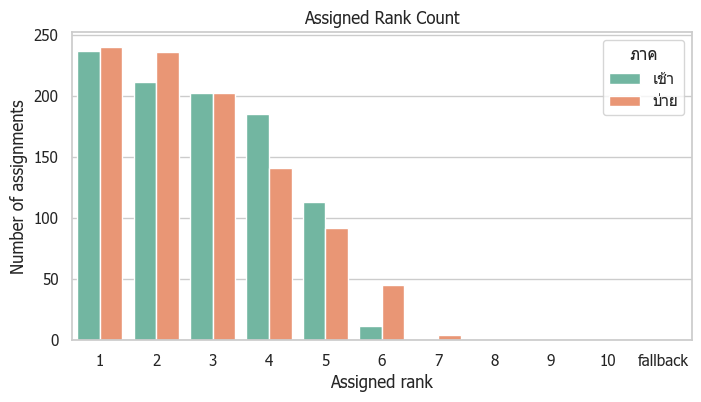

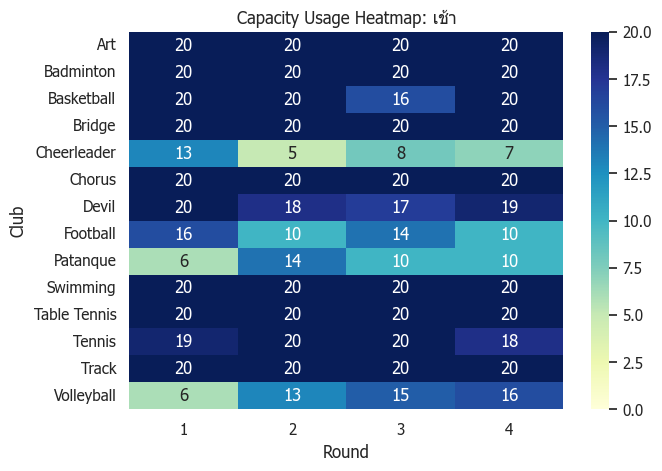

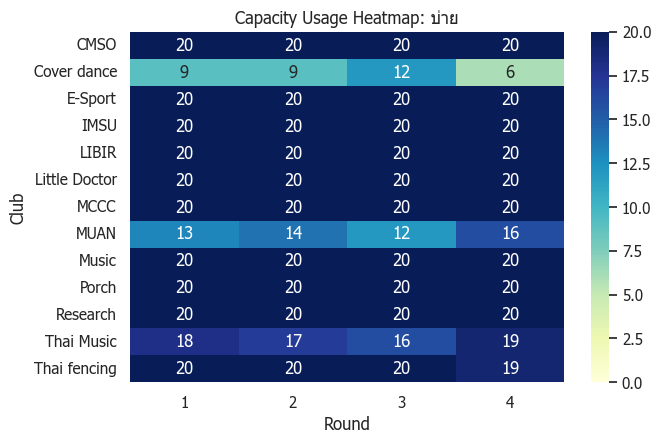

In [8]:
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = ['Tahoma', 'DejaVu Sans']

rank_data = result_long.copy()
rank_data['อันดับที่เลือก'] = rank_data['อันดับที่เลือก'].astype(str)

plt.figure(figsize=(8, 4))
rank_order = ['1', '2', '3', '4', '5', '6', '7', '8','9','10', 'fallback']
sns.countplot(data=rank_data, x='อันดับที่เลือก', hue='ภาค', order=rank_order, palette='Set2')
plt.title('Assigned Rank Count')
plt.xlabel('Assigned rank')
plt.ylabel('Number of assignments')
plt.show()

for session_name in capacity['ภาค'].unique():
    session_capacity = capacity[capacity['ภาค'] == session_name]
    heatmap_data = session_capacity.pivot(index='ชมรม', columns='รอบ', values='จำนวนที่จัด')

    plt.figure(figsize=(7, max(4, len(heatmap_data) * 0.35)))
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu', vmin=0, vmax=MAX_PER_CLUB)
    plt.title(f'Capacity Usage Heatmap: {session_name}')
    plt.xlabel('Round')
    plt.ylabel('Club')
    plt.show()

In [9]:
# เช็คจำนวนคนเลือกแต่ละชมรม แยกตามภาคและอันดับ 1-10
# แสดงผลแนวนอน ยึดตามชมรม

CHECK_MAX_RANK = 10

morning_check_cols = [f'ชมรมช่วงเช้า [อันดับที่ {i}]' for i in range(1, CHECK_MAX_RANK + 1)]
afternoon_check_cols = [f'ชมรมช่วงบ่าย [อันดับที่ {i}]' for i in range(1, CHECK_MAX_RANK + 1)]

def count_club_choices_wide(df, session_name, columns):
    rows = []

    for rank, col in enumerate(columns, start=1):
        if col not in df.columns:
            print(f'ไม่พบคอลัมน์: {col}')
            continue

        counts = (
            df[col]
            .dropna()
            .astype(str)
            .str.strip()
        )

        counts = counts[counts != '']
        counts = counts.value_counts().reset_index()
        counts.columns = ['ชมรม', f'อันดับ {rank}']

        counts['ภาค'] = session_name

        rows.append(counts)

    if not rows:
        rank_cols = [f'อันดับ {i}' for i in range(1, CHECK_MAX_RANK + 1)]
        return pd.DataFrame(columns=['ภาค', 'ชมรม'] + rank_cols)

    result = rows[0]

    for table in rows[1:]:
        result = result.merge(table, on=['ภาค', 'ชมรม'], how='outer')

    rank_cols = [f'อันดับ {i}' for i in range(1, CHECK_MAX_RANK + 1)]

    for col in rank_cols:
        if col not in result.columns:
            result[col] = 0

    result[rank_cols] = result[rank_cols].fillna(0).astype(int)

    result = result[['ภาค', 'ชมรม'] + rank_cols]
    result = result.sort_values(['ภาค', 'ชมรม']).reset_index(drop=True)

    return result

morning_choice_count = count_club_choices_wide(df, 'เช้า', morning_check_cols)
afternoon_choice_count = count_club_choices_wide(df, 'บ่าย', afternoon_check_cols)

choice_count_wide = pd.concat(
    [morning_choice_count, afternoon_choice_count],
    ignore_index=True
)

choice_count_wide

,ภาค,ชมรม,อันดับ 1,อันดับ 2,อันดับ 3,อันดับ 4,อันดับ 5,อันดับ 6,อันดับ 7,อันดับ 8,อันดับ 9,อันดับ 10
0,เช้า,Art,19,25,22,20,16,18,8,13,24,26
1,เช้า,Badminton,57,51,41,31,19,13,7,6,8,2
2,เช้า,Basketball,27,14,7,11,24,16,20,33,16,14
3,เช้า,Bridge,26,25,19,24,19,15,7,9,17,14
4,เช้า,Cheerleader,13,1,5,10,6,6,6,6,12,25
5,เช้า,Chorus,20,19,16,20,9,13,10,12,18,13
6,เช้า,Devil,11,24,19,13,13,9,15,13,10,21
7,เช้า,Football,19,10,7,5,9,15,22,8,19,13
8,เช้า,Patanque,5,7,5,10,18,19,13,26,23,26
9,เช้า,Swimming,6,17,20,22,22,21,17,20,18,22
